# Cross-Model Comparison (RQ3)

Spearman rank correlation of subject ECE between GPT-4o-mini and Llama-3-8B.
Identify task-driven vs. model-specific miscalibration.

In [1]:
import os
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())
import sys
sys.path.insert(0, 'src')
import pandas as pd
import matplotlib.pyplot as plt
from modeling.cross_model import main as run_cross_model

run_cross_model()
comp = pd.read_parquet('data/processed/cross_model_comparison.parquet')
comp.head()

Spearman rank correlation (ECE): rho=0.806, 95% CI [0.671, 0.886]

Agreement breakdown:
agreement
both (task-driven)    49
gpt4o only             8


,subject,ece_gpt4o,ece_llama,reject_gpt4o,reject_llama,domain,agreement
0,abstract_algebra,0.420346,0.292200,True,True,STEM,both (task-driven)
1,anatomy,0.182184,0.166965,True,True,STEM,both (task-driven)
2,astronomy,0.081513,0.190924,True,True,STEM,both (task-driven)
3,business_ethics,0.180004,0.199542,True,True,Other,both (task-driven)
4,clinical_knowledge,0.114582,0.125999,True,True,Other,both (task-driven)


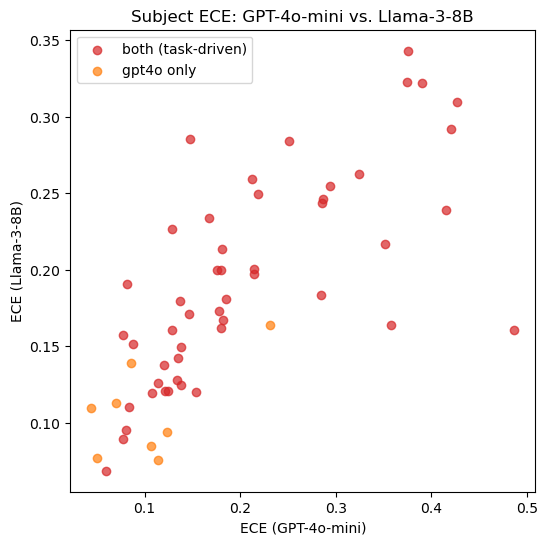

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = {'both (task-driven)': 'tab:red', 'gpt4o only': 'tab:orange',
          'llama only': 'tab:blue', 'neither': 'tab:gray'}
for grp, sub in comp.groupby('agreement'):
    ax.scatter(sub['ece_gpt4o'], sub['ece_llama'], label=grp,
               color=colors[grp], alpha=0.7)
ax.set_xlabel('ECE (GPT-4o-mini)')
ax.set_ylabel('ECE (Llama-3-8B)')
ax.legend()
ax.set_title('Subject ECE: GPT-4o-mini vs. Llama-3-8B')
plt.savefig('report/figures/cross_model_ece.pdf', bbox_inches='tight')

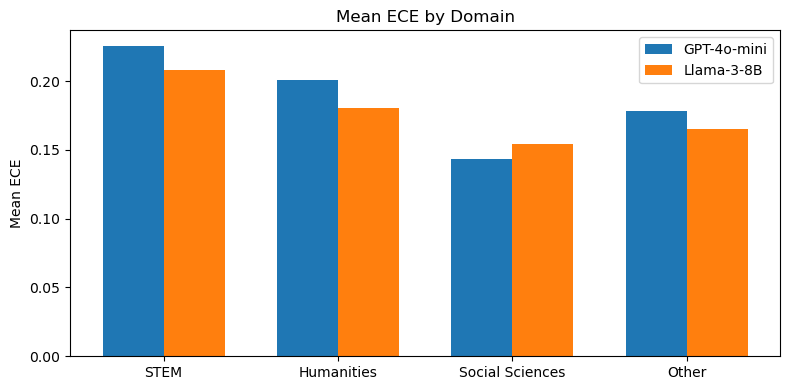

In [3]:
# Plot 2: Mean ECE by domain for both models
import numpy as np

domains = ['STEM', 'Humanities', 'Social Sciences', 'Other']
x = np.arange(len(domains))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
for i, (model, label) in enumerate([('gpt4o', 'GPT-4o-mini'), ('llama', 'Llama-3-8B')]):
    summ = pd.read_parquet(f'data/processed/subject_summaries_{model}.parquet')
    domain_ece = summ.groupby('domain')['ece'].mean().reindex(domains)
    ax.bar(x + (i - 0.5) * width, domain_ece, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(domains)
ax.set_ylabel('Mean ECE')
ax.set_title('Mean ECE by Domain')
ax.legend()
plt.tight_layout()
plt.savefig('report/figures/domain_ece.pdf', bbox_inches='tight')


=== gpt4o: n=14,042 questions, 57 subjects ===


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: calibration_gap
No. Observations: 14042   Method:             REML           
No. Groups:       4       Scale:              0.1499         
Min. group size:  2879    Log-Likelihood:     -6700.3918     
Max. group size:  4705    Converged:          Yes            
Mean group size:  3510.5                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.196    0.016 12.551 0.000  0.165  0.227
word_count          0.031    0.006  5.204 0.000  0.019  0.042
max_choice_len      0.001    0.004  0.191 0.848 -0.008  0.009
has_negation       -0.001    0.010 -0.063 0.950 -0.020  0.019
entropy             0.016    0.004  4.299 0.000  0.009  0.023
subject Var         0.013    0.007                           


ICC Decomposition:

/opt/anaconda3/envs/215b-final/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: calibration_gap
No. Observations: 14042   Method:             REML           
No. Groups:       4       Scale:              0.1905         
Min. group size:  2879    Log-Likelihood:     -8359.1741     
Max. group size:  4705    Converged:          Yes            
Mean group size:  3510.5                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.155    0.012 13.367 0.000  0.132  0.178
word_count          0.015    0.006  2.343 0.019  0.002  0.028
max_choice_len     -0.002    0.005 -0.464 0.642 -0.011  0.007
has_negation        0.014    0.011  1.263 0.207 -0.008  0.036
entropy            -0.014    0.004 -3.180 0.001 -0.022 -0.005
subject Var         0.006    0.003                           


ICC Decomposition:

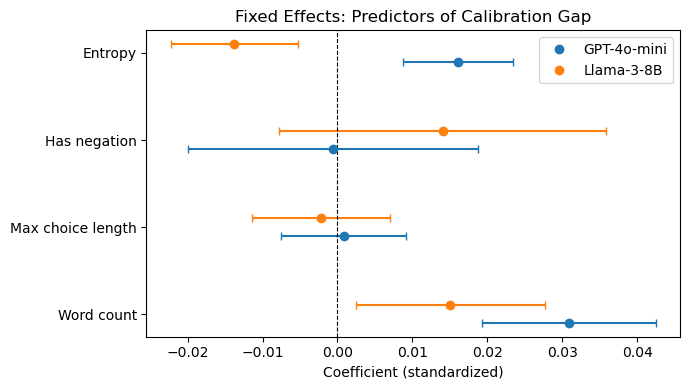

In [4]:
# Plot 3: Coefficient forest plot (fixed effects from multilevel model)
from modeling import multilevel
from matplotlib.lines import Line2D

covariates = ['word_count', 'max_choice_len', 'has_negation', 'entropy']
labels = ['Word count', 'Max choice length', 'Has negation', 'Entropy']
coef_data = {}
for model in ['gpt4o', 'llama']:
    result, icc, blups = multilevel.run(model)
    ci = result.conf_int()
    coef_data[model] = {'params': result.fe_params, 'ci_lo': ci[0], 'ci_hi': ci[1]}

y = np.arange(len(covariates))
fig, ax = plt.subplots(figsize=(7, 4))
for i, (model, label) in enumerate([('gpt4o', 'GPT-4o-mini'), ('llama', 'Llama-3-8B')]):
    params = coef_data[model]['params']
    ci_lo = coef_data[model]['ci_lo']
    ci_hi = coef_data[model]['ci_hi']
    for j, cov in enumerate(covariates):
        ax.errorbar(params[cov], y[j] + (i - 0.5) * 0.2,
                    xerr=[[params[cov] - ci_lo[cov]], [ci_hi[cov] - params[cov]]],
                    fmt='o', color=f'C{i}', capsize=3)

ax.axvline(0, color='k', linestyle='--', lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (standardized)')
ax.set_title('Fixed Effects: Predictors of Calibration Gap')
ax.legend(handles=[Line2D([0],[0],marker='o',color='C0',linestyle='',label='GPT-4o-mini'),
                   Line2D([0],[0],marker='o',color='C1',linestyle='',label='Llama-3-8B')])
plt.tight_layout()
plt.savefig('report/figures/coef_plot.pdf', bbox_inches='tight')

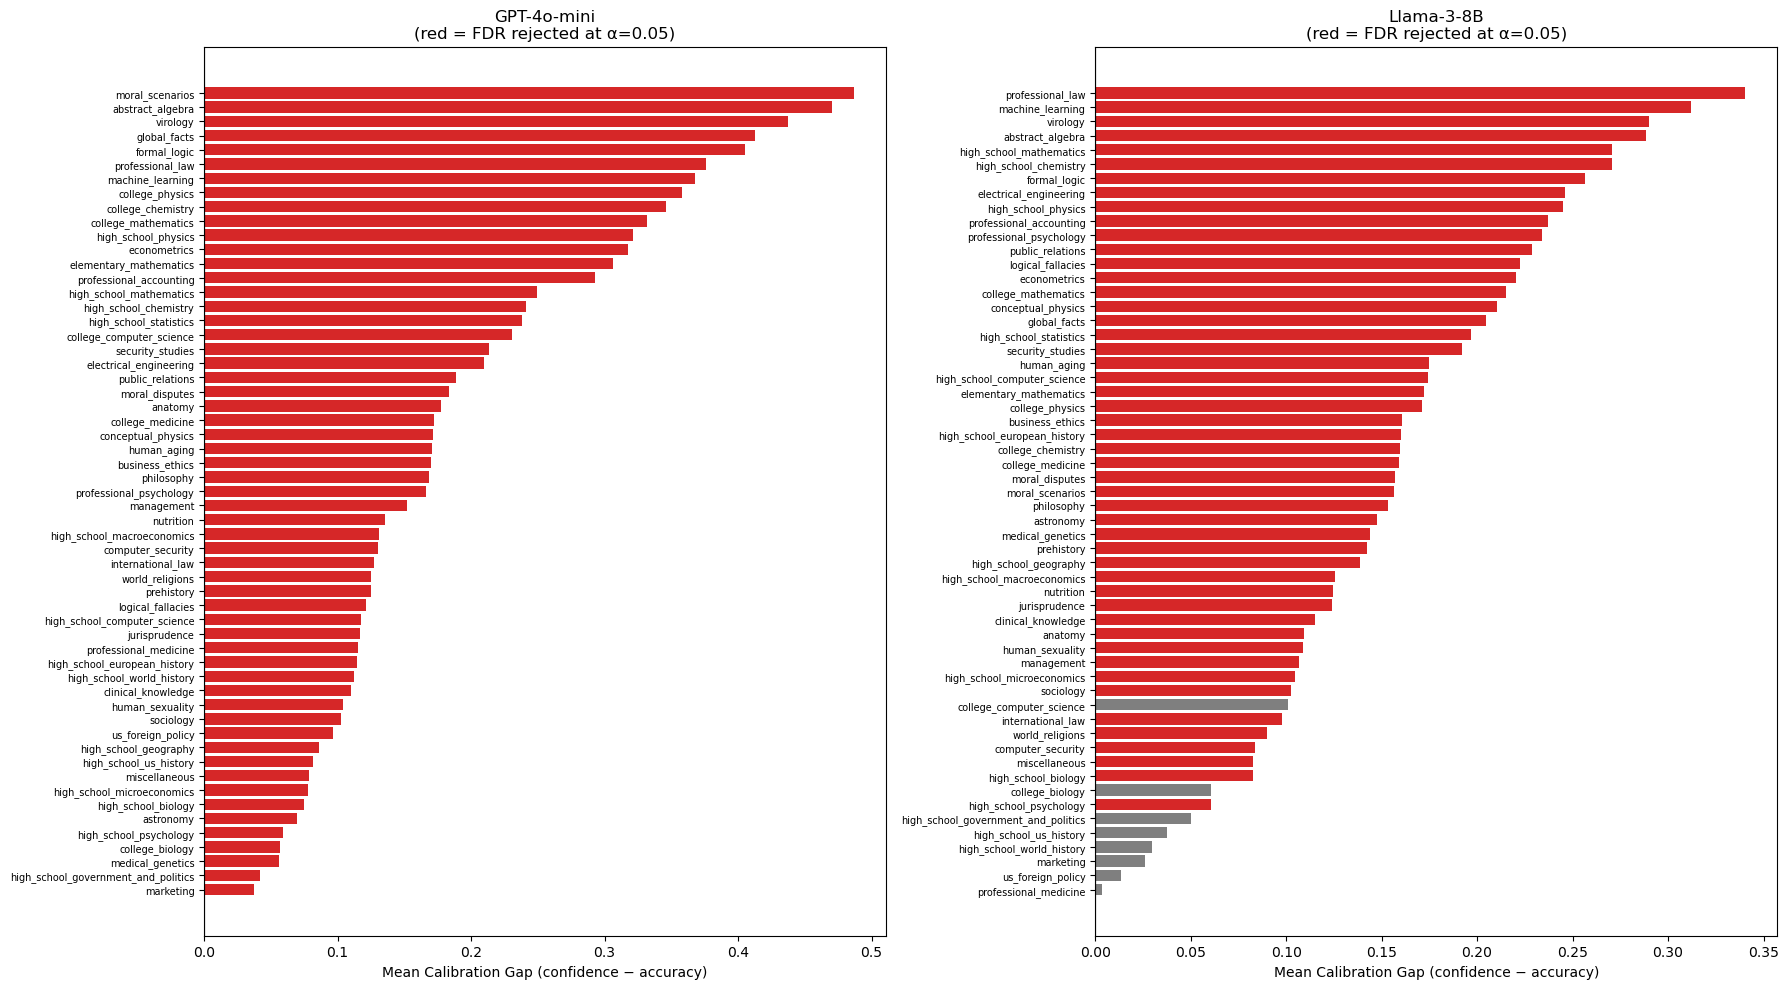

In [5]:
# Plot 4: Sorted subject mean_gap bar chart for both models
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
for ax, model, label in zip(axes, ['gpt4o', 'llama'], ['GPT-4o-mini', 'Llama-3-8B']):
    fdr = pd.read_parquet(f'data/processed/fdr_results_{model}.parquet').sort_values('mean_gap', ascending=True)
    colors = ['tab:red' if r else 'tab:gray' for r in fdr['reject']]
    ax.barh(range(len(fdr)), fdr['mean_gap'], color=colors)
    ax.set_yticks(range(len(fdr)))
    ax.set_yticklabels(fdr['subject'], fontsize=7)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Mean Calibration Gap (confidence − accuracy)')
    ax.set_title(f'{label}\n(red = FDR rejected at α=0.05)')
plt.tight_layout()
plt.savefig('report/figures/subject_mean_gap.pdf', bbox_inches='tight')